Zelle 1 — Städte laden

Diese Zelle fragt über eine SPARQL-Anfrage bei Wikidata alle deutschen Städte mit mehr als 100.000 Einwohnern ab, inklusive ihrer Koordinaten. Das Ergebnis landet als sortiertes DataFrame in cities_df. Die Basis für alle folgenden Schritte.

In [4]:
# Deutsche Großstädte >150.000 Einwohner mit Koordinaten (Wikidata-SPARQL-API)
import requests
import pandas as pd
import numpy as np
import time

def get_german_cities(min_population=150000):
    # SPARQL-Query: Stadt in Deutschland, mit Einwohnerzahl und Koordinaten
    query = f"""
    SELECT DISTINCT ?cityLabel ?population ?coord WHERE {{
      ?city wdt:P31/wdt:P279* wd:Q515;      # ist eine Stadt
            wdt:P17 wd:Q183;                # liegt in Deutschland
            wdt:P1082 ?population;          # hat Einwohnerzahl
            wdt:P625 ?coord.                # hat Koordinaten
      FILTER(?population >= {min_population})
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "de,en". }}
    }}
    ORDER BY DESC(?population)
    """
    url = "https://query.wikidata.org/sparql"
    headers = {"Accept": "application/sparql-results+json", "User-Agent": "student-project/1.0"}
    r = requests.get(url, params={"query": query}, headers=headers)
    r.raise_for_status()  # Fehler werfen, falls Anfrage fehlschlägt

    rows = r.json()["results"]["bindings"]
    cities = []
    for row in rows:
        name = row["cityLabel"]["value"]
        pop = int(row["population"]["value"])
        # Koordinaten kommen als Text "Point(lon lat)" -> aufsplitten
        lon, lat = row["coord"]["value"].replace("Point(", "").replace(")", "").split(" ")
        cities.append({"city": name, "population": pop, "lat": float(lat), "lon": float(lon)})

    df = pd.DataFrame(cities).drop_duplicates(subset="city")  # Duplikate entfernen
    return df.sort_values("population", ascending=False).reset_index(drop=True)

cities_df = get_german_cities(min_population=150000)
print(cities_df)
print(f"Anzahl Städte: {len(cities_df)}")

                       city  population        lat        lon
0                    Berlin     3782202  52.516667  13.383333
1                   Hamburg     1910160  53.550000  10.000000
2                   München     1510378  48.137500  11.575000
3                      Köln     1024621  50.942222   6.957778
4         Frankfurt am Main      775790  50.110556   8.682222
5   Freie Hansestadt Bremen      693204  53.133333   8.733333
6                 Stuttgart      633484  48.777500   9.180000
7                Düsseldorf      631217  51.225556   6.776667
8                   Leipzig      611850  51.340632  12.374733
9                  Dortmund      595471  51.513889   7.465278
10                    Essen      586608  51.450833   7.013056
11                   Bremen      577026  53.075833   8.807222
12                  Dresden      564904  51.049329  13.738144
13                 Hannover      548186  52.374444   9.738611
14                 Nürnberg      529508  49.453889  11.077500
15      

Statt einer normalen requests.Session bauen wir eine requests_cache.CachedSession (persistenter SQLite-Cache, nie ablaufend, nur echte 200er-Antworten werden gespeichert) und montieren darauf unsere eigene Retry-Strategie inklusive 429. Diese Session wird an den openmeteo_requests-Client übergeben, der die eigentliche Kommunikation (inkl. FlatBuffers-Parsing) übernimmt.

In [5]:
# Open-Meteo-Client: FlatBuffers-Client + persistenter Cache + eigene Retry-Logik (inkl. 429)
import openmeteo_requests
import requests_cache
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

def make_client():
    cache_session = requests_cache.CachedSession(
        "openmeteo_cache",      # Datei: openmeteo_cache.sqlite
        expire_after=-1,         # nie ablaufen -- Klimadaten ändern sich nicht rückwirkend
        allowable_codes=[200],   # 429/Fehler werden NIE gecacht
    )
    retry = Retry(
        total=6, backoff_factor=3,                       # 3s, 6s, 12s, 24s, 48s, 96s
        status_forcelist=[429, 500, 502, 503, 504],       # 429 explizit dabei
        allowed_methods=["GET"],
    )
    cache_session.mount("https://", HTTPAdapter(max_retries=retry))
    cache_session.headers.update({"User-Agent": "student-project/1.0"})
    return openmeteo_requests.Client(session=cache_session)

CLIENT = make_client()

fetch_tmax_batch nutzt jetzt CLIENT.weather_api(...) statt session.get(...) und baut die Koordinatenlisten direkt als Python-Listen (keine Komma-Strings mehr nötig). Die restlichen drei Funktionen (Schwellenwerte, Hitzewellen-Erkennung, Verknüpfung) bleiben inhaltlich exakt wie zuvor.

In [6]:
# Funktionen: Wetterdaten laden (openmeteo_requests) + Hitzewellen erkennen
import time

ARCHIVE_URL = "https://archive-api.open-meteo.com/v1/archive"

def fetch_tmax_batch(client, coords, start_date, end_date, batch_size=15, pause=5):
    """Holt Tages-Maximaltemperaturen für mehrere Städte gleichzeitig."""
    dfs = []
    n_batches = -(-len(coords) // batch_size)  # aufrunden

    for b in range(n_batches):
        i = b * batch_size
        chunk = coords[i:i + batch_size]  # ein Batch von Städten

        params = {
            "latitude": [lat for lat, lon in chunk],
            "longitude": [lon for lat, lon in chunk],
            "start_date": start_date, "end_date": end_date,
            "daily": ["temperature_2m_max"],
            "timezone": "Europe/Berlin",
        }
        try:
            responses = client.weather_api(ARCHIVE_URL, params=params)  # immer eine Liste
        except Exception as e:
            raise RuntimeError(f"API-Fehler bei Batch {b+1}/{n_batches}: {e}") from e

        for response in responses:
            daily = response.Daily()
            tmax = daily.Variables(0).ValuesAsNumpy()  # 0 = einzige angeforderte Variable
            dates = pd.date_range(
                start=pd.to_datetime(daily.Time(), unit="s", utc=True),
                end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
                freq=pd.Timedelta(seconds=daily.Interval()),
                inclusive="left",
            ).tz_localize(None)  # Zeitzone abstreifen, reine Kalendertage reichen
            dfs.append(pd.DataFrame({"date": dates, "tmax": tmax}))

        aus_cache = getattr(responses[0], "from_cache", False) if hasattr(responses[0], "from_cache") else False
        print(f"  Batch {b+1}/{n_batches} ok ({len(chunk)} Städte)")
        time.sleep(pause)

    return dfs

def fetch_tmax_range(client, coords, start_date, end_date, batch_size=15, year_chunk=5, pause=5):
    """Holt Tmax über einen langen Zeitraum, aufgeteilt in Städte-Batches
    UND Jahres-Blöcke -- jede einzelne Anfrage bleibt klein, Fortschritt
    ist granular im HTTP-Cache gesichert."""
    start_year, end_year = int(start_date[:4]), int(end_date[:4])

    year_ranges = []
    y = start_year
    while y <= end_year:
        y2 = min(y + year_chunk - 1, end_year)
        year_ranges.append((f"{y}-01-01", f"{y2}-12-31"))
        y = y2 + 1

    all_parts = {i: [] for i in range(len(coords))}
    for chunk_start, chunk_end in year_ranges:
        print(f"Zeitraum {chunk_start[:4]}-{chunk_end[:4]}:")
        dfs = fetch_tmax_batch(client, coords, chunk_start, chunk_end, batch_size=batch_size, pause=pause)
        for i, df in enumerate(dfs):
            all_parts[i].append(df)
        time.sleep(pause)  # zusätzlicher Puffer zwischen Zeitblöcken

    return [pd.concat(all_parts[i], ignore_index=True).sort_values("date").reset_index(drop=True)
            for i in range(len(coords))]
    

def compute_doy_thresholds(ref_df, window=15, percentile=98):
    """Schwellenwert pro Kalendertag: 98. Perzentil aus ±15 Tagen der Referenzperiode."""
    doy = ref_df["doy"].to_numpy()
    tmax = ref_df["tmax"].to_numpy()
    thresholds = {}

    for d in range(1, 366):
        dist = np.abs(doy - d)
        dist = np.minimum(dist, 365 - dist)  # Jahreswechsel berücksichtigen
        thresholds[d] = np.percentile(tmax[dist <= window], percentile)

    return thresholds


def find_dwd_heatwaves(df, thresholds, min_days=3, fixed_threshold=28.0):
    """Hitzewelle = mind. 3 Tage in Folge über Klima-Schwelle UND über 28°C."""
    df = df.copy()
    df["doy"] = df["date"].dt.dayofyear.clip(upper=365)
    df["threshold"] = df["doy"].map(thresholds)
    df["is_hot"] = (df["tmax"] > df["threshold"]) & (df["tmax"] > fixed_threshold)

    heatwaves, start = [], None
    for i, row in df.iterrows():
        if row["is_hot"] and start is None:
            start = i
        elif not row["is_hot"] and start is not None:
            segment = df.loc[start:i - 1]
            if len(segment) >= min_days:
                heatwaves.append({
                    "start": segment["date"].iloc[0].date(),
                    "end": segment["date"].iloc[-1].date(),
                    "duration_days": len(segment),
                    "max_temp": round(segment["tmax"].max(), 1),
                    "avg_temp": round(segment["tmax"].mean(), 1)
                })
            start = None

    if start is not None:
        segment = df.loc[start:]
        if len(segment) >= min_days:
            heatwaves.append({
                "start": segment["date"].iloc[0].date(),
                "end": segment["date"].iloc[-1].date(),
                "duration_days": len(segment),
                "max_temp": round(segment["tmax"].max(), 1),
                "avg_temp": round(segment["tmax"].mean(), 1)
            })

    return heatwaves


def analyze_city_heatwaves_from_data(ref_df, analysis_df):
    """Verbindet Schwellenwert-Berechnung und Hitzewellen-Suche für eine Stadt."""
    ref_df = ref_df.copy()
    ref_df["doy"] = ref_df["date"].dt.dayofyear.clip(upper=365)
    thresholds = compute_doy_thresholds(ref_df)
    return find_dwd_heatwaves(analysis_df, thresholds)

Prüft mit 3 Städten und einem Monat, ob der neue Client korrekt antwortet, bevor der volle Lauf startet.

In [7]:
# Kurztest: prüfen ob Client + fetch_tmax_batch funktionieren (3 Städte, ein Monat)
coords = list(zip(cities_df["lat"], cities_df["lon"]))

test = fetch_tmax_batch(CLIENT, coords[:3], "2025-01-01", "2025-01-31")
[len(df) for df in test]   # sollte 3x ~31 ergeben

  Batch 1/1 ok (3 Städte)


[31, 31, 31]

Kein manuelles Pickle-Caching mehr nötig — das übernimmt jetzt die CachedSession aus Zelle 2 transparent auf HTTP-Ebene. Bei einem 429 mitten im Lauf: Zelle einfach später erneut ausführen, bereits erfolgreiche Requests kommen sofort aus dem Cache.

In [8]:
#Fuer cache aufrufe DAS HIER NEHMEN!!
ref_dfs = fetch_tmax_range(CLIENT, coords, "1961-01-01", "1990-12-31", batch_size=15, year_chunk=10, pause=1)

Zeitraum 1961-1970:
  Batch 1/4 ok (15 Städte)
  Batch 2/4 ok (15 Städte)
  Batch 3/4 ok (15 Städte)
  Batch 4/4 ok (12 Städte)
Zeitraum 1971-1980:
  Batch 1/4 ok (15 Städte)
  Batch 2/4 ok (15 Städte)
  Batch 3/4 ok (15 Städte)
  Batch 4/4 ok (12 Städte)
Zeitraum 1981-1990:
  Batch 1/4 ok (15 Städte)
  Batch 2/4 ok (15 Städte)
  Batch 3/4 ok (15 Städte)
  Batch 4/4 ok (12 Städte)


In [9]:
#time.sleep(120) 
analysis_dfs = fetch_tmax_range(CLIENT, coords, "1980-01-01", "2025-12-31", batch_size=15, year_chunk=5, pause=1)

Zeitraum 1980-1984:
  Batch 1/4 ok (15 Städte)
  Batch 2/4 ok (15 Städte)
  Batch 3/4 ok (15 Städte)
  Batch 4/4 ok (12 Städte)
Zeitraum 1985-1989:
  Batch 1/4 ok (15 Städte)
  Batch 2/4 ok (15 Städte)
  Batch 3/4 ok (15 Städte)
  Batch 4/4 ok (12 Städte)
Zeitraum 1990-1994:
  Batch 1/4 ok (15 Städte)
  Batch 2/4 ok (15 Städte)
  Batch 3/4 ok (15 Städte)
  Batch 4/4 ok (12 Städte)
Zeitraum 1995-1999:
  Batch 1/4 ok (15 Städte)
  Batch 2/4 ok (15 Städte)
  Batch 3/4 ok (15 Städte)
  Batch 4/4 ok (12 Städte)
Zeitraum 2000-2004:
  Batch 1/4 ok (15 Städte)
  Batch 2/4 ok (15 Städte)
  Batch 3/4 ok (15 Städte)
  Batch 4/4 ok (12 Städte)
Zeitraum 2005-2009:
  Batch 1/4 ok (15 Städte)
  Batch 2/4 ok (15 Städte)
  Batch 3/4 ok (15 Städte)
  Batch 4/4 ok (12 Städte)
Zeitraum 2010-2014:
  Batch 1/4 ok (15 Städte)
  Batch 2/4 ok (15 Städte)
  Batch 3/4 ok (15 Städte)
  Batch 4/4 ok (12 Städte)
Zeitraum 2015-2019:
  Batch 1/4 ok (15 Städte)
  Batch 2/4 ok (15 Städte)
  Batch 3/4 ok (15 Städte)
  B

In [11]:
exclude_idx = {5}  # Freie Hansestadt Bremen -- Bundesland, nicht die Stadt; ggf. Indizes aus Diagnose oben ergänzen

In [12]:
# Referenzperiode (1961-1990) und Analysejahr (2025) laden, dann Hitzewellen berechnen
results = []
failed_cities = []

for idx, row in cities_df.iterrows():
    if idx in exclude_idx:
        continue
    try:
        heatwaves = analyze_city_heatwaves_from_data(ref_dfs[idx], analysis_dfs[idx])
        for hw in heatwaves:
            results.append({"city": row["city"], "population": row["population"], **hw})
    except Exception as e:
        print(f"  Übersprungen wegen Fehler ({row['city']}): {e}")
        failed_cities.append(row["city"])

results_df = pd.DataFrame(results)
print(results_df)
print(f"\nFehlgeschlagen: {failed_cities}")

            city  population       start         end  duration_days  \
0         Berlin     3782202  1982-05-31  1982-06-04              5   
1         Berlin     3782202  1992-06-01  1992-06-04              4   
2         Berlin     3782202  1992-08-07  1992-08-09              3   
3         Berlin     3782202  1994-07-21  1994-07-31             11   
4         Berlin     3782202  1997-08-23  1997-08-25              3   
...          ...         ...         ...         ...            ...   
1561  Regensburg      151517  2022-08-02  2022-08-04              3   
1562  Regensburg      151517  2023-08-18  2023-08-21              4   
1563  Regensburg      151517  2024-08-28  2024-08-31              4   
1564  Regensburg      151517  2025-06-28  2025-07-01              4   
1565  Regensburg      151517  2025-08-12  2025-08-14              3   

       max_temp   avg_temp  
0     32.000000  30.400000  
1     28.799999  28.600000  
2     37.700001  35.599998  
3     36.700001  33.200001  
4 

In [13]:
starts = pd.to_datetime(results_df["start"])
print(f"Gefundene Hitzewellen gesamt: {len(results_df)}")
print(f"Zeitraum: {starts.dt.year.min()} bis {starts.dt.year.max()}")

Gefundene Hitzewellen gesamt: 1566
Zeitraum: 1982 bis 2025


In [28]:
import os

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

raw_rows = []
for idx, row in cities_df.iterrows():
    if idx in exclude_idx:
        continue
    df = analysis_dfs[idx].copy()
    df["city"] = row["city"]
    raw_rows.append(df)
raw_df = pd.concat(raw_rows, ignore_index=True)
raw_df.to_parquet("data/raw/tmax_1980_2025.parquet", index=False)

results_df["year"] = pd.to_datetime(results_df["start"]).dt.year
results_df.to_csv("data/processed/heatwaves.csv", index=False)

In [22]:
all_years = pd.DataFrame({"year": range(1980, 2026)})
yearly = all_years.merge(
    results_df.groupby("year").agg(
        n_heatwaves=("city", "count"),
        avg_max_temp=("max_temp", "mean"),
        avg_avg_temp=("avg_temp", "mean"),
        avg_duration=("duration_days", "mean"),
    ).reset_index(),
    on="year", how="left"
)
yearly["n_heatwaves"] = yearly["n_heatwaves"].fillna(0).astype(int)
print(yearly)

    year  n_heatwaves  avg_max_temp  avg_avg_temp  avg_duration
0   1980            0           NaN           NaN           NaN
1   1981            0           NaN           NaN           NaN
2   1982           48     29.875000     29.266668      3.791667
3   1983           11     34.636364     33.281818      3.000000
4   1984            0           NaN           NaN           NaN
5   1985            0           NaN           NaN           NaN
6   1986            1     31.200001     30.400000      3.000000
7   1987            0           NaN           NaN           NaN
8   1988            0           NaN           NaN           NaN
9   1989            0           NaN           NaN           NaN
10  1990           27     34.085186     32.614815      3.111111
11  1991            8     28.625000     28.424999      3.000000
12  1992           29     33.937931     32.713795      3.068966
13  1993            0           NaN           NaN           NaN
14  1994           73     32.624660     

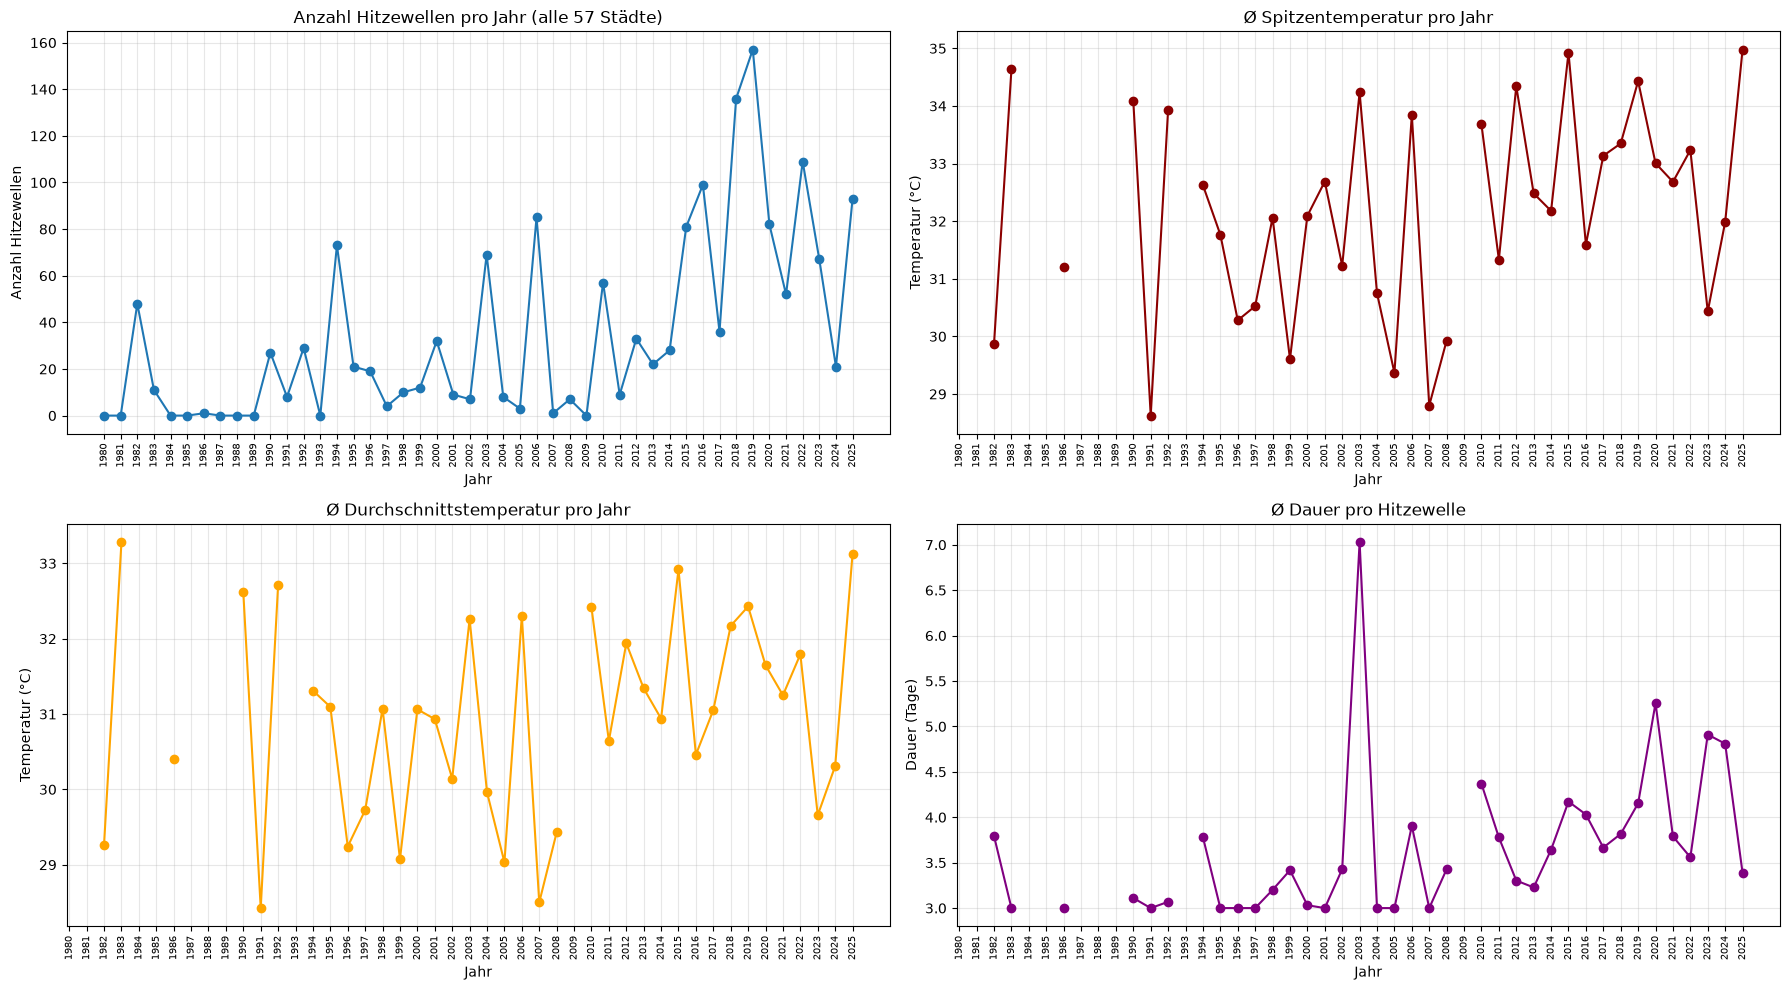

In [29]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
all_years_range = np.arange(1980, 2026)

def style_axis(ax, ylabel):
    ax.set_xlabel("Jahr")
    ax.set_ylabel(ylabel)
    ax.set_xticks(all_years_range)
    ax.set_xticklabels(all_years_range, rotation=90, fontsize=7)
    ax.grid(axis="x", alpha=0.3)
    ax.grid(axis="y", alpha=0.3)

axes[0,0].plot(yearly["year"], yearly["n_heatwaves"], marker="o")
axes[0,0].set_title("Anzahl Hitzewellen pro Jahr (alle 57 Städte)")
style_axis(axes[0,0], "Anzahl Hitzewellen")

axes[0,1].plot(yearly["year"], yearly["avg_max_temp"], marker="o", color="darkred")
axes[0,1].set_title("Ø Spitzentemperatur pro Jahr")
style_axis(axes[0,1], "Temperatur (°C)")

axes[1,0].plot(yearly["year"], yearly["avg_avg_temp"], marker="o", color="orange")
axes[1,0].set_title("Ø Durchschnittstemperatur pro Jahr")
style_axis(axes[1,0], "Temperatur (°C)")

axes[1,1].plot(yearly["year"], yearly["avg_duration"], marker="o", color="purple")
axes[1,1].set_title("Ø Dauer pro Hitzewelle")
style_axis(axes[1,1], "Dauer (Tage)")

plt.tight_layout()
plt.savefig("data/processed/trend_overview.png", dpi=150)
plt.show()

In [24]:
from scipy import stats

for col, label in [("n_heatwaves", "Häufigkeit"), ("avg_max_temp", "Spitzentemp."),
                    ("avg_avg_temp", "Durchschnittstemp."), ("avg_duration", "Dauer")]:
    valid = yearly.dropna(subset=[col])
    slope, intercept, r, p, se = stats.linregress(valid["year"], valid[col])
    signif = "signifikant" if p < 0.05 else "nicht signifikant"
    print(f"{label}: {slope:+.3f}/Jahr, p={p:.4f} ({signif}), R²={r**2:.3f}, n={len(valid)}")

Häufigkeit: +1.815/Jahr, p=0.0000 (signifikant), R²=0.372, n=46
Spitzentemp.: +0.039/Jahr, p=0.1124 (nicht signifikant), R²=0.070, n=37
Durchschnittstemp.: +0.021/Jahr, p=0.2579 (nicht signifikant), R²=0.036, n=37
Dauer: +0.028/Jahr, p=0.0106 (signifikant), R²=0.173, n=37


In [25]:
yearly_no_overlap = yearly[yearly["year"] >= 1991]

from scipy import stats
for col, label in [("n_heatwaves", "Häufigkeit"), ("avg_max_temp", "Spitzentemp."),
                    ("avg_avg_temp", "Durchschnittstemp."), ("avg_duration", "Dauer")]:
    valid = yearly_no_overlap.dropna(subset=[col])
    slope, intercept, r, p, se = stats.linregress(valid["year"], valid[col])
    signif = "signifikant" if p < 0.05 else "nicht signifikant"
    print(f"{label} (nur 1991–2025, keine Überlappung): {slope:+.3f}/Jahr, p={p:.4f} ({signif}), R²={r**2:.3f}, n={len(valid)}")

Häufigkeit (nur 1991–2025, keine Überlappung): +2.279/Jahr, p=0.0005 (signifikant), R²=0.312, n=35
Spitzentemp. (nur 1991–2025, keine Überlappung): +0.067/Jahr, p=0.0254 (signifikant), R²=0.151, n=33
Durchschnittstemp. (nur 1991–2025, keine Überlappung): +0.043/Jahr, p=0.0546 (nicht signifikant), R²=0.114, n=33
Dauer (nur 1991–2025, keine Überlappung): +0.033/Jahr, p=0.0202 (signifikant), R²=0.162, n=33
